In [48]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [49]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################

df_kzhn = pd.read_excel("База_соц_эконом_неоднор_регионов.xlsx", sheet_name="КЖН (рейтинг)")
df_kf = pd.read_excel("База_соц_эконом_неоднор_регионов.xlsx", sheet_name="Коэф фондов", skiprows=2)

df_kf = df_kf.iloc[:, [1, 2, 3]]       # берем только Region, Date, KF
df_kf.columns = ["Region", "Date", "KF"]

df_kzhn["Date"] = pd.to_numeric(df_kzhn["Date"], errors="coerce")
df_kzhn["K_PLQ"] = pd.to_numeric(df_kzhn["K_PLQ"], errors="coerce")
df_kzhn = df_kzhn.dropna(subset=["Region", "Date", "K_PLQ"])

df_kf["Region"] = df_kf["Region"].astype(str).str.strip()
df_kf["Date"] = pd.to_numeric(df_kf["Date"], errors="coerce")
df_kf["KF"] = pd.to_numeric(df_kf["KF"], errors="coerce")
df_kf = df_kf.dropna(subset=["Region", "Date", "KF"])

df = df_kzhn.merge(df_kf, on=["Region", "Date"], how="inner")

# Выбираем за какие годы проводим кластеризацию
df_recent = df[df["Date"].isin([2019, 2020, 2021, 2022, 2023, 2024])]
df_year = df_recent.groupby("Region", as_index=False).agg(K_PLQ=("K_PLQ", "mean"), KF=("KF", "mean"))


df_clust = df_year[["Region", "K_PLQ", "KF"]].dropna().copy()

X = df_clust[["K_PLQ", "KF"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [50]:
###############################
    #ПОДБОР ЧИСЛА КЛАСТЕРОВ
###############################
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels_k)
    silhouette_scores.append(sil)
    print(f"k={k}: inertia={km.inertia_:.2f}, silhouette={sil:.4f}")

k=2: inertia=99.24, silhouette=0.4225
k=3: inertia=75.53, silhouette=0.4307
k=4: inertia=54.44, silhouette=0.3730
k=5: inertia=41.59, silhouette=0.4021
k=6: inertia=33.38, silhouette=0.3997
k=7: inertia=27.45, silhouette=0.3625
k=8: inertia=24.92, silhouette=0.3559
k=9: inertia=22.30, silhouette=0.3662
k=10: inertia=19.10, silhouette=0.3577


In [51]:
###############################
    #ФИНАЛЬНАЯ КЛАСТЕРИЗАЦИЯ
###############################

optimal_k = 3  # можно поменять, исходя из вывода выше
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_clust["Cluster"] = kmeans.fit_predict(X_scaled) + 1

In [54]:
closest_regions = []

for cl in sorted(df_clust["Cluster"].unique()):
    mask = df_clust["Cluster"] == cl
    points = X_scaled[mask]

    # индекс центроида = номер кластера - 1
    center = kmeans.cluster_centers_[cl - 1]

    dists = np.linalg.norm(points - center, axis=1)
    idx_min = dists.argmin()

    row_closest = df_clust[mask].iloc[idx_min]
    closest_regions.append(row_closest)

closest_df = pd.DataFrame(closest_regions)
print(closest_df[["Cluster", "Region", "K_PLQ", "KF"]])


    Cluster                                             Region      K_PLQ  \
40        1                                  Псковская область  45.184167   
77        2                         Чукотский автономный округ  41.723833   
80        3  в том числе Ханты-Мансийский автономный округ ...  62.842333   

           KF  
40  10.916667  
77  17.400000  
80  13.466667  


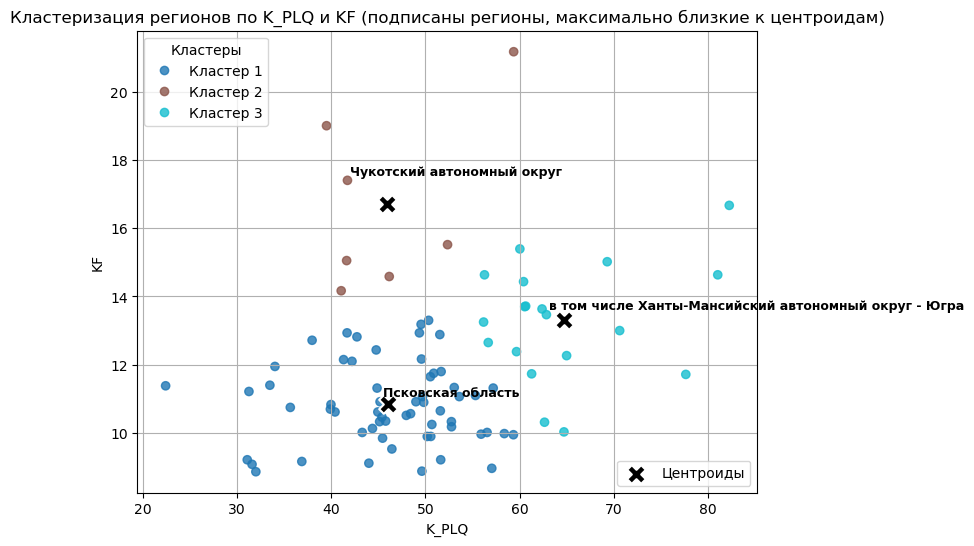

In [53]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df_clust["K_PLQ"],
    df_clust["KF"],
    c=df_clust["Cluster"],
    cmap="tab10",
    alpha=0.8
)

# центроиды 
centers = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    c="black",
    s=180,
    marker="X",
    edgecolor="white",
    linewidth=1.5,
    label="Центроиды"
)

# подписи только ближайших регионов
for _, row in closest_df.iterrows():
    plt.text(
        row["K_PLQ"] + 0.3,
        row["KF"] + 0.15,
        row["Region"],
        fontsize=9,
        fontweight="bold"
    )

plt.xlabel("K_PLQ")
plt.ylabel("KF")
plt.title("Кластеризация регионов по K_PLQ и KF (подписаны регионы, максимально близкие к центроидам)")

handles, _ = scatter.legend_elements(prop="colors", num=None)
labels = [f"Кластер {k}" for k in sorted(df_clust["Cluster"].unique())]
cluster_legend = plt.legend(handles, labels, title="Кластеры", loc="upper left")
plt.gca().add_artist(cluster_legend)
plt.legend(loc="lower right")

plt.grid(True)
plt.show()


In [55]:
cluster_summary = df_clust.groupby("Cluster").agg(
    mean_K_PLQ=("K_PLQ", "mean"),
    median_K_PLQ=("K_PLQ", "median"),
    mean_KF=("KF", "mean"),
    median_KF=("KF", "median"),
    count=("Region", "count")
).reset_index()

print(cluster_summary)

   Cluster  mean_K_PLQ  median_K_PLQ    mean_KF  median_KF  count
0        1   46.080619     47.967167  10.841243  10.700000     59
1        2   45.971214     41.723833  16.697619  15.516667      7
2        3   64.741123     62.379000  13.296930  13.466667     19


In [56]:
# просто список регионов по каждому кластеру
clusters_regions = (
    df_clust
    .sort_values(["Cluster", "Region"])
    .groupby("Cluster")["Region"]
    .apply(list)
    .reset_index(name="Regions")
)
for _, row in clusters_regions.iterrows():
    cluster_id = row["Cluster"]
    regions = row["Regions"]  
    print(f"Кластер {cluster_id}:")
    for r in regions:
        print(f"  - {r}")
    print()  

Кластер 1:
  - Алтайский край
  - Архангельская область
  - Астраханская область
  - Брянская область
  - Владимирская область
  - Волгоградская область
  - Вологодская область
  - Еврейская автономная область
  - Забайкальский край
  - Ивановская область
  - Иркутская область
  - Кабардино-Балкарская Республика
  - Калужская область
  - Камчатский край
  - Карачаево-Черкесская Республика
  - Кемеровская область
  - Кировская область
  - Костромская область
  - Красноярский край
  - Курганская область
  - Курская область
  - Мурманская область
  - Новгородская область
  - Омская область
  - Оренбургская область
  - Орловская область
  - Пензенская область
  - Пермский край
  - Приморский край
  - Псковская область
  - Республика Алтай
  - Республика Бурятия
  - Республика Дагестан
  - Республика Ингушетия
  - Республика Калмыкия
  - Республика Карелия
  - Республика Коми
  - Республика Крым
  - Республика Марий Эл
  - Республика Мордовия
  - Республика Северная Осетия - Алания
  - Респ

In [57]:
region_cluster = df_clust[['Region', 'Cluster']].copy()
region_cluster.head()

,Region,Cluster
0,Алтайский край,1
1,Амурская область,2
2,Архангельская область,1
3,Астраханская область,1
4,Белгородская область,3


In [58]:
cluster_dummies = pd.get_dummies(region_cluster['Cluster'],prefix='Cluster').astype(int)

region_cluster = pd.concat([region_cluster, cluster_dummies], axis=1)

region_cluster = region_cluster.drop(columns=['Cluster', 'Cluster_3'])

region_cluster.head()

,Region,Cluster_1,Cluster_2
0,Алтайский край,1,0
1,Амурская область,0,1
2,Архангельская область,1,0
3,Астраханская область,1,0
4,Белгородская область,0,0


In [59]:
pickle_filename = 'region_cluster_dataset.pkl'
with open(pickle_filename, 'wb') as f:
    pickle.dump(region_cluster, f)